# Project 2 — Book lengths in characters, words, and tokens

**Chapter 2 · Tokenization** · pp. 28–30

Import 10 out-of-copyright books from Project Gutenberg and compare their lengths in **characters**, **words**, and **GPT-2 tokens** — total and unique.

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

In [2]:
### matplotlib adjustments
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,
})


# **How to import a book from gutenberg.org**

In [3]:
url = "https://www.gutenberg.org/cache/epub/84/pg84.txt"
text = requests.get(url).text
print(text[:1000])

The Project Gutenberg eBook of Frankenstein; or, the modern prometheus
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Frankenstein; or, the modern prometheus

Author: Mary Wollstonecraft Shelley


        
Release date: October 1, 1993 [eBook #84]
                Most recently updated: February 10, 2026

Language: English

Other information and formats: www.gutenberg.org/ebooks/84

Credits: Judith Boss, Christy Phillips, Lynn Hanninen and David Meltzer. HTML version by Al Haines.
        Further corrections by Menno de Leeuw.


*** START OF THE PROJECT GUTEN


# **Part 1: Total characters, words, and tokens**

In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

/Users/johnmachado/Desktop/50 ML Projects to Understand LLMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# all books have the same url format;
# they are unique by numerical code
baseurl = "https://www.gutenberg.org/cache/epub/"

bookurls = [
    # code       title
    ["84", "Frankenstein"],
    ["64317", "GreatGatsby"],
    ["11", "AliceWonderland"],
    ["1513", "RomeoJuliet"],
    ["76", "HuckFinn"],
    ["219", "HeartDarkness"],
    ["2591", "GrimmsTales"],
    ["2148", "EdgarAllenPoe"],
    ["36", "WarOfTheWorlds"],
    ["829", "GulliversTravels"]
]

In [6]:
print(f"{'Book title':16} | {'Chars':>9} | {'Words':>9} | {'Tokens':>9}")
print(f"{'-'*16}-+-{'-'*9}-+-{'-'*9}-+-{'-'*9}")

for code, title in bookurls:

    # get the text
    fullurl = baseurl + code + "/pg" + code + ".txt"
    text = requests.get(fullurl).text

    characters = [c for c in text]
    words = text.split()
    tokens = tokenizer.encode(text)

    # counts of different token types
    n_chars = len(characters) # number of characters in text
    n_words = len(words)      # number of words (split text on whitespace)
    n_tokens = len(tokens)    # number of GPT-2 tokens (encode text)

    print(f"{title:16} | {n_chars:>9,} | {n_words:>9,} | {n_tokens:>9,}") 

Book title       |     Chars |     Words |    Tokens
-----------------+-----------+-----------+----------


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


Frankenstein     |   446,582 |    78,106 |   114,213
GreatGatsby      |   296,899 |    51,262 |    89,263
AliceWonderland  |   167,712 |    29,569 |    52,948
RomeoJuliet      |   167,469 |    29,005 |    56,180
HuckFinn         |   602,752 |   114,130 |   193,373
HeartDarkness    |   232,924 |    40,957 |    63,988
GrimmsTales      |   549,776 |   104,156 |   158,433
EdgarAllenPoe    |   632,171 |    98,105 |   197,302
WarOfTheWorlds   |   363,440 |    63,118 |    96,422
GulliversTravels |   611,781 |   108,140 |   158,340


# **Part 2: Unique and total counts**

In [7]:
# Note: The books are redundantly downloaded.
# In principle it would be more efficient to download only once and then store the texts in Python,
# but the code is fast and there aren't many books, so it's OK here. :)

In [8]:
# initialize
totals = np.zeros((3, len(bookurls)))
uniques = np.zeros((3, len(bookurls)))

# loop over books
for i, (code, title) in enumerate(bookurls):

    # get the text
    fullurl = baseurl + code + "/pg" + code + ".txt"
    text = requests.get(fullurl).text

    # count the total and unique characters
    totals[0, i] = len(text)
    uniques[0, i] = len(set(text))

    # repeat for words
    words = text.split()
    totals[1, i] = len(words)
    uniques[1, i] = len(set(words))

    # and for tokens
    tokens = tokenizer.encode(text)
    totals[2, i] = len(tokens)
    uniques[2, i] = len(set(tokens))

In [9]:
print("Totals:\n", totals)
print("\nUniques:\n", uniques)

Totals:
 [[446582. 296899. 167712. 167469. 602752. 232924. 549776. 632171. 363440.
  611781.]
 [ 78106.  51262.  29569.  29005. 114130.  40957. 104156.  98105.  63118.
  108140.]
 [114213.  89263.  52948.  56180. 193373.  63988. 158433. 197302.  96422.
  158340.]]

Uniques:
 [[   94.    95.    92.    92.    89.    91.    92.   111.    92.    94.]
 [12179. 10210.  5973.  6957. 14308.  9555. 10918. 18445. 11417. 14491.]
 [ 9239.  8151.  4510.  5196.  8353.  7486.  7152. 11225.  9131. 10274.]]


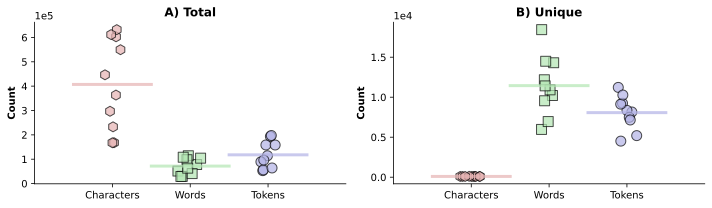

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(10, 3))

# marker colors and shapes
colors = [[.9, .7, .7, .7], [.7, .9, .7, .7], [.7, .7, .9, .7]]
shapes = "hso"

# loop over the three tokenizer features (0=chars, 1=words, 2=tokens)
for i in range(3):

    # individual data points (10 books, jittered around x=i)
    axs[0].plot(
        np.random.normal(
            i, 
            .06, 
            len(bookurls)
        ),
        totals[i, :],
        "k" + shapes[i],
        markerfacecolor=colors[i],
        markersize=10
    )

    # the mean (a short horizontal line at the average)
    axs[0].plot(
        [i - .5, i + .5],
        np.mean(totals[i, :]) * np.ones(2),
        color=colors[i],
        linewidth=3
    )

    # repeat for unique counts
    axs[1].plot(
        np.random.normal(
            i,
            .06,
            len(bookurls)
        ),
        uniques[i, :],
        "k" + shapes[i],
        markerfacecolor=colors[i],
        markersize=10
    )

    axs[1].plot(
        [i - .5, i + .5],
        np.mean(uniques[i, :]) * np.ones(2),
        color=colors[i],
        linewidth=3
    )

# axis adjustments
axs[0].set(
    xticks=[0, 1, 2],
    xticklabels=["Characters", "Words", "Tokens"],
    xlim=[-1, 3],
    ylabel="Count",
    title="A) Total"
)

axs[1].set(
    xticks=[0, 1, 2],
    xticklabels=["Characters", "Words", "Tokens"],
    xlim=[-1, 3],
    ylabel="Count",
    title="B) Unique"
)

axs[0].ticklabel_format(
    style="scientific",
    axis="y",
    scilimits=(0, 0)
)

axs[1].ticklabel_format(
    style="scientific",
    axis="y",
    scilimits=(0, 0)
)

plt.tight_layout()
plt.savefig("images/ch2-proj2-pt2.png")
plt.show()

**How to read this figure:** each dot is one of the 10 books.

Within each group, the marker shape tells you the measure — **hexagons = characters**, **squares = words**, **circles = tokens** — and the short **horizontal bar is the mean** across all 10 books.

Panel **A) Total** shows raw counts.

Panel **B) Unique** shows distinct counts.

*(The dots are nudged slightly left and right so they don't sit on top of each other — only their **height** carries meaning, not their horizontal position.)*